<a href="https://colab.research.google.com/github/mananmalvi/ML--The-Art/blob/main/DAY-11-IGNIS_NET_WildFire__AI_(Random_Forest_Classification_Based).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

In [ ]:
# ==========================================
# PHASE 1: DATA EXTRACTION (Your Custom Script)
# ==========================================
import pandas as pd
import numpy as np
import requests
from io import StringIO

print("🌍 Initiating Ignis-Net AI: Fetching and Sanitizing Raw Data...")

url = "https://raw.githubusercontent.com/krishnaik06/Complete-Machine-Learning-2023/main/Algerian_forest_fires_dataset_UPDATE.csv"

response = requests.get(url)
response.raise_for_status()

lines = response.text.splitlines()

cleaned_lines = []
current_region = None

for line in lines:
    # Detect region
    if "Bejaia Region Dataset" in line:
        current_region = "Bejaia"
        continue
    elif "Sidi-Bel Abbes Region Dataset" in line:
        current_region = "Sidi-Bel Abbes"
        continue

    # Skip empty lines
    if line.strip() == "":
        continue

    # Keep header only once
    if "day,month,year" in line.lower():
        if len(cleaned_lines) == 0:
            cleaned_lines.append(line + ",Region")
        continue

    # Add region to valid data rows
    cleaned_lines.append(line + f",{current_region}")

# Convert to DataFrame
cleaned_csv = "\n".join(cleaned_lines)
df = pd.read_csv(StringIO(cleaned_csv))

# Clean column names
df.columns = df.columns.str.strip()

# Clean string values
df["Classes"] = df["Classes"].astype(str).str.strip()
df["Region"] = df["Region"].astype(str).str.strip()

# Create target
df["Fire_Risk"] = np.where(df["Classes"].str.lower() == "fire", 1, 0)
df.drop("Classes", axis=1, inplace=True)

# Convert numerical columns
numeric_columns = df.columns.difference(["Region"])
df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors="coerce")

# 🛠️ FIX 1: Drop any rows that became NaN during the coercion process
df = df.dropna().reset_index(drop=True)

# 🛠️ FIX 2: Encode the string-based 'Region' column into numeric (0 and 1) for Sklearn
df["Region"] = np.where(df["Region"] == "Bejaia", 0, 1)

print("\n✅ Data Extraction Complete")
print(f"📊 Cleaned Shape: {df.shape}")

print("\n📋 Columns:")
print(df.columns.tolist())

print("\n🔥 Target Distribution:")
print(df["Fire_Risk"].value_counts())

print("\n❓ Missing Values:")
print(df.isnull().sum())

🌍 Initiating Ignis-Net AI: Fetching and Sanitizing Raw Data...

✅ Data Extraction Complete
📊 Cleaned Shape: (243, 15)

📋 Columns:
['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Region', 'Fire_Risk']

🔥 Target Distribution:
Fire_Risk
1    137
0    106
Name: count, dtype: int64

❓ Missing Values:
day            0
month          0
year           0
Temperature    0
RH             0
Ws             0
Rain           0
FFMC           0
DMC            0
DC             0
ISI            0
BUI            0
FWI            0
Region         0
Fire_Risk      0
dtype: int64


In [ ]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region,Fire_Risk
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [ ]:
df.tail()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region,Fire_Risk
238,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5,1,1
239,27,9,2012,28,87,15,4.4,41.1,6.5,8.0,0.1,6.2,0.0,1,0
240,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2,1,0
241,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7,1,0
242,30,9,2012,24,64,15,0.2,67.3,3.8,16.5,1.2,4.8,0.5,1,0


In [ ]:
# ==========================================
# 🔥 IGNIS-NET AI
# STEP 2 — DATA AUDIT & EDA
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------
# 1️⃣ Basic Dataset Overview
# ------------------------------------------

print("📊 Dataset Shape:", df.shape)

print("\n📋 Data Types:")
print(df.dtypes)

print("\n📈 Statistical Summary:")
display(df.describe().T)


📊 Dataset Shape: (243, 15)

📋 Data Types:
day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
Region           int64
Fire_Risk        int64
dtype: object

📈 Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
day,243.0,15.761317,8.842552,1.0,8.00,16.0,23.00,31.0
month,243.0,7.502058,1.114793,6.0,7.00,8.0,8.00,9.0
year,243.0,2012.000000,0.000000,2012.0,2012.00,2012.0,2012.00,2012.0
Temperature,243.0,32.152263,3.628039,22.0,30.00,32.0,35.00,42.0
RH,243.0,62.041152,14.828160,21.0,52.50,63.0,73.50,90.0
Ws,243.0,15.493827,2.811385,6.0,14.00,15.0,17.00,29.0
Rain,243.0,0.762963,2.003207,0.0,0.00,0.0,0.50,16.8
FFMC,243.0,77.842387,14.349641,28.6,71.85,83.3,88.30,96.0
DMC,243.0,14.680658,12.393040,0.7,5.80,11.3,20.80,65.9
DC,243.0,49.430864,47.665606,6.9,12.35,33.1,69.10,220.4



🔥 Fire Risk Distribution:
Fire_Risk
1    137
0    106
Name: count, dtype: int64

🔥 Fire Risk Percentage:
Fire_Risk
1    56.38
0    43.62
Name: proportion, dtype: float64


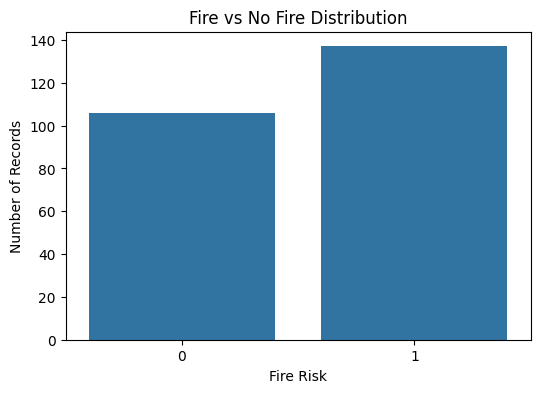

In [ ]:
# ------------------------------------------
# 2️⃣ Target Distribution
# ------------------------------------------

print("\n🔥 Fire Risk Distribution:")
print(df["Fire_Risk"].value_counts())

print("\n🔥 Fire Risk Percentage:")
print((df["Fire_Risk"].value_counts(normalize=True) * 100).round(2))


plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Fire_Risk")
plt.title("Fire vs No Fire Distribution")
plt.xlabel("Fire Risk")
plt.ylabel("Number of Records")
plt.show()

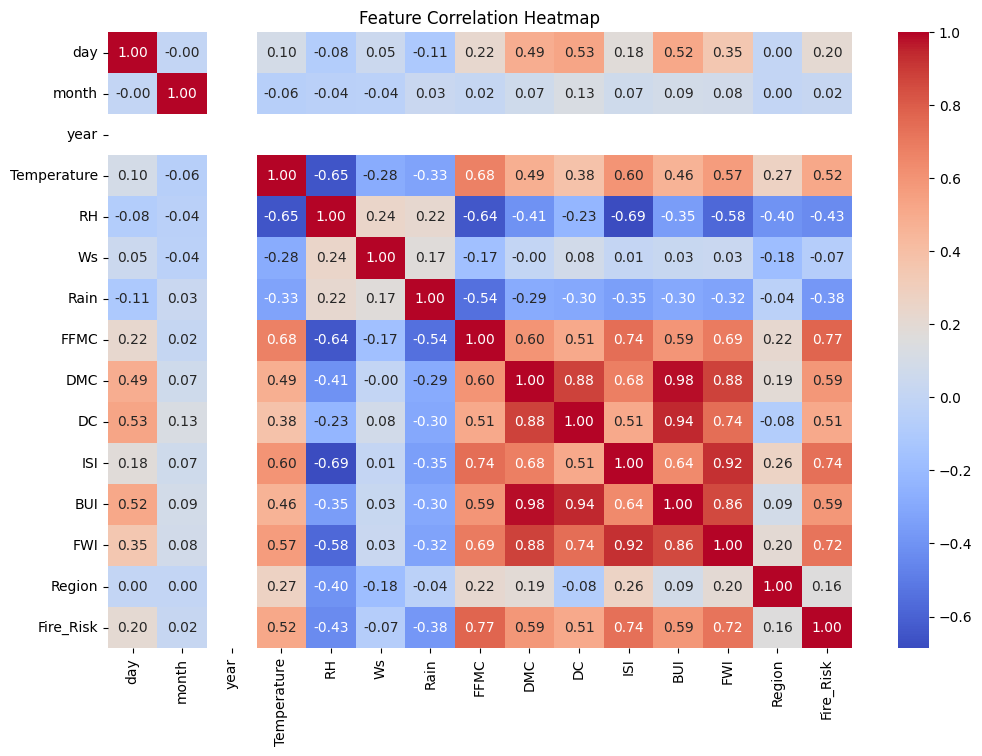

In [ ]:
# ------------------------------------------
# 3️⃣ Correlation Heatmap
# ------------------------------------------

plt.figure(figsize=(12, 8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")
plt.show()

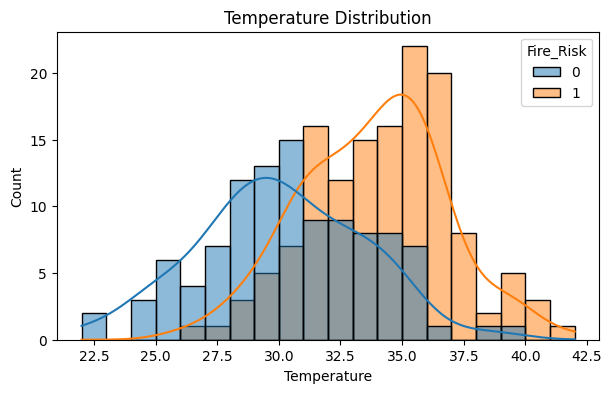

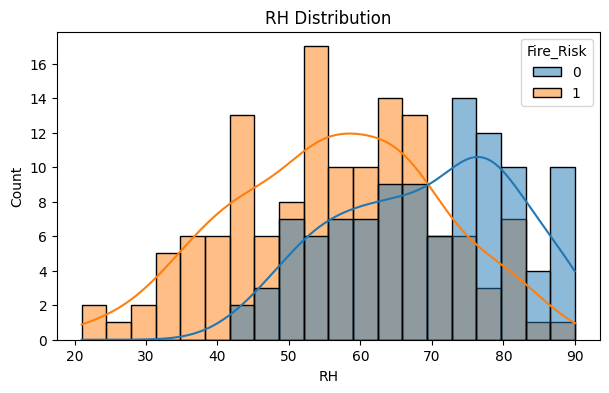

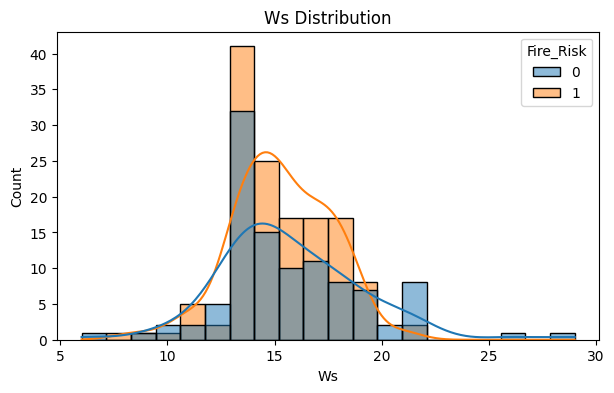

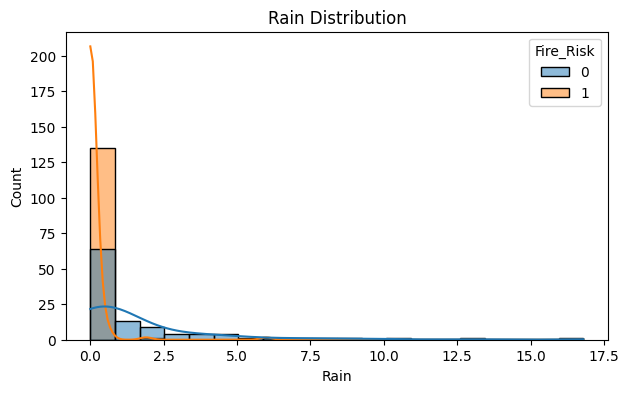

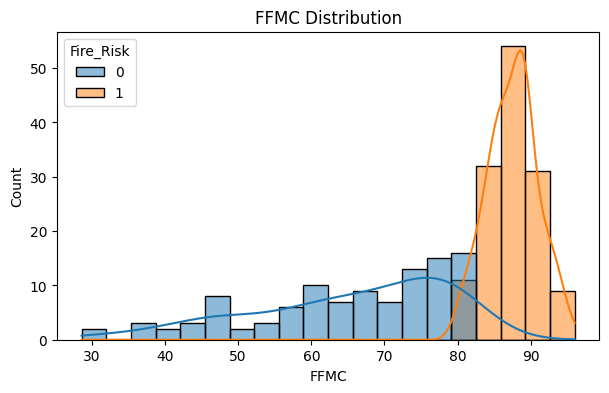

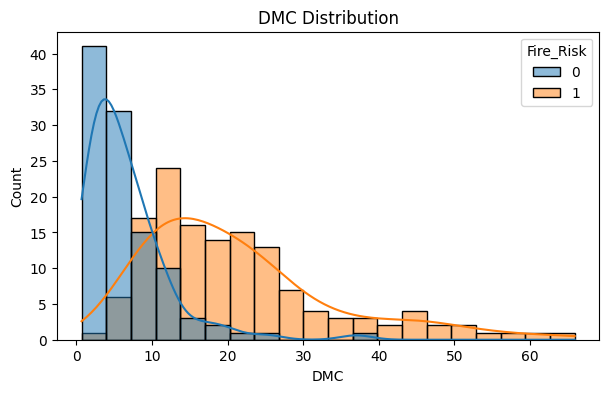

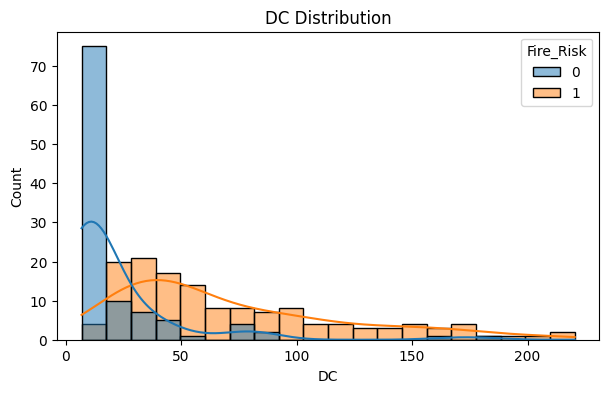

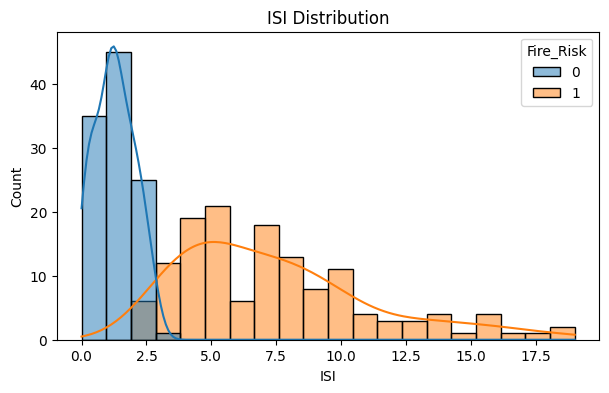

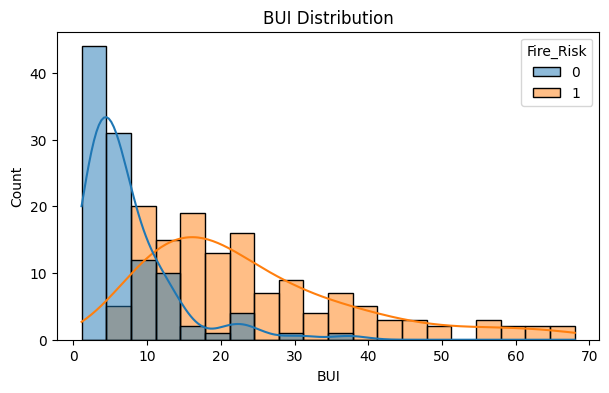

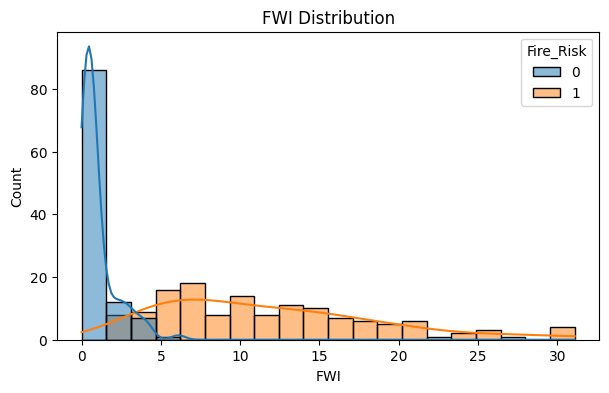

In [ ]:
# ------------------------------------------
# 4️⃣ Feature Distributions
# ------------------------------------------

features = [
    "Temperature",
    "RH",
    "Ws",
    "Rain",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "BUI",
    "FWI"
]

for feature in features:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=feature,
        hue="Fire_Risk",
        kde=True,
        bins=20
    )

    plt.title(f"{feature} Distribution")
    plt.show()

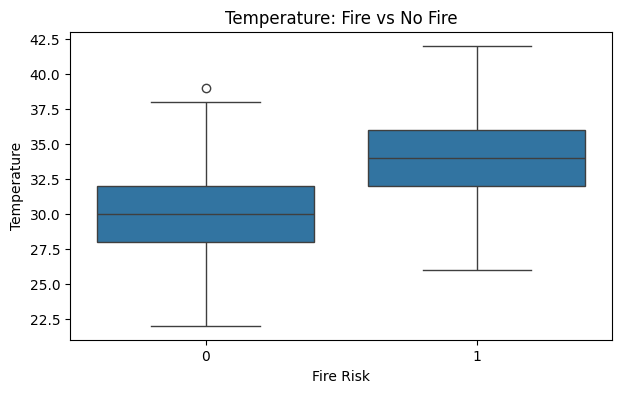

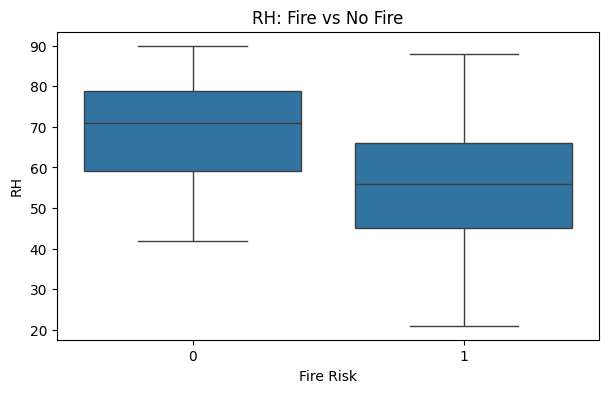

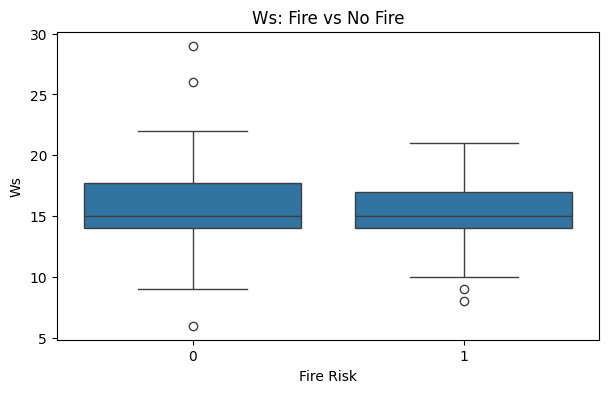

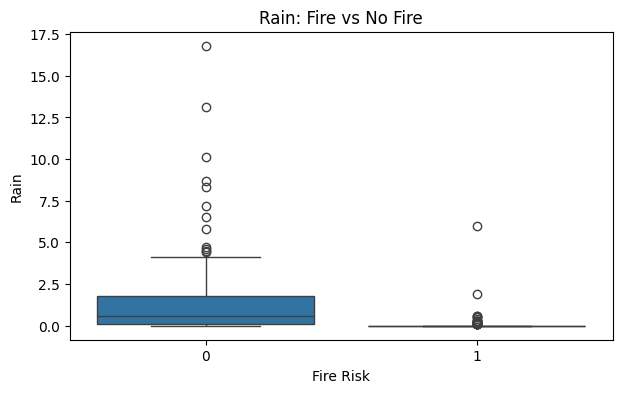

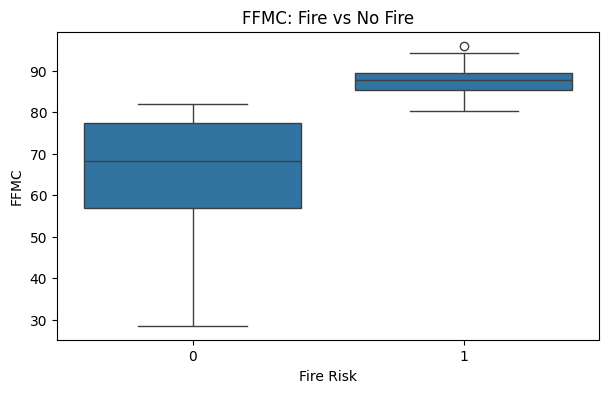

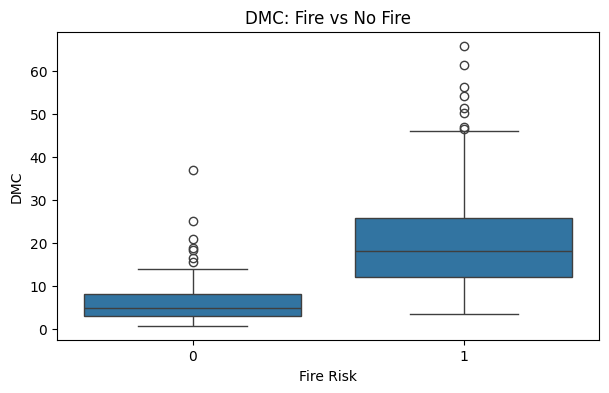

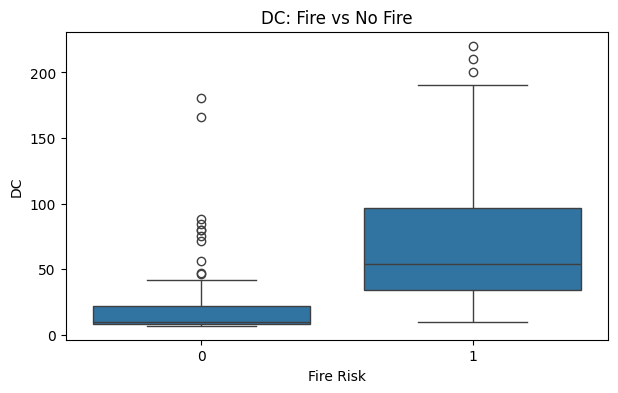

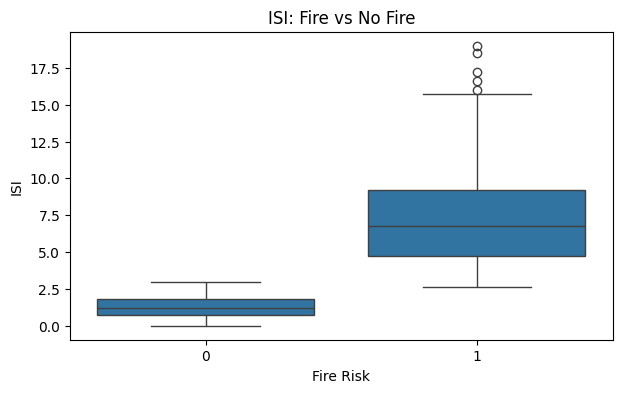

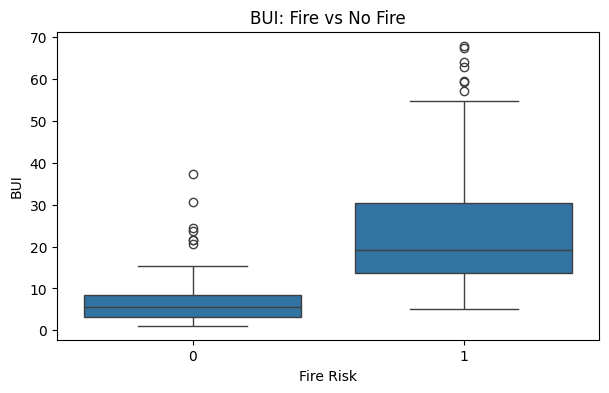

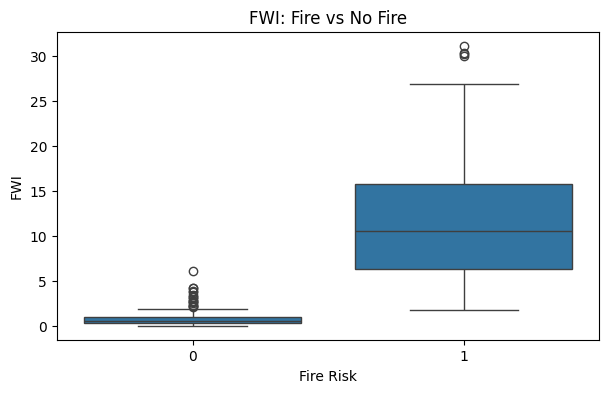

In [ ]:
# ------------------------------------------
# 5️⃣ Fire vs No-Fire Boxplots
# ------------------------------------------

for feature in features:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x="Fire_Risk",
        y=feature
    )

    plt.title(f"{feature}: Fire vs No Fire")
    plt.xlabel("Fire Risk")
    plt.ylabel(feature)
    plt.show()


🌍 Fire Risk by Region:


Fire_Risk,0,1
Region,,
0,51.6,48.4
1,35.5,64.5


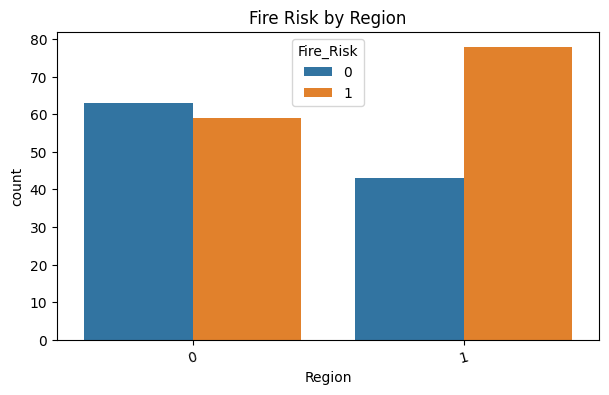

In [ ]:
# ------------------------------------------
# 6️⃣ Region Analysis
# ------------------------------------------

print("\n🌍 Fire Risk by Region:")
display(
    pd.crosstab(
        df["Region"],
        df["Fire_Risk"],
        normalize="index"
    ).round(3) * 100
)


plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x="Region",
    hue="Fire_Risk"
)

plt.title("Fire Risk by Region")
plt.xticks(rotation=15)
plt.show()


📅 Fire Risk by Month:


Fire_Risk,0,1
month,,
6,58.3,41.7
7,37.7,62.3
8,17.7,82.3
9,61.7,38.3


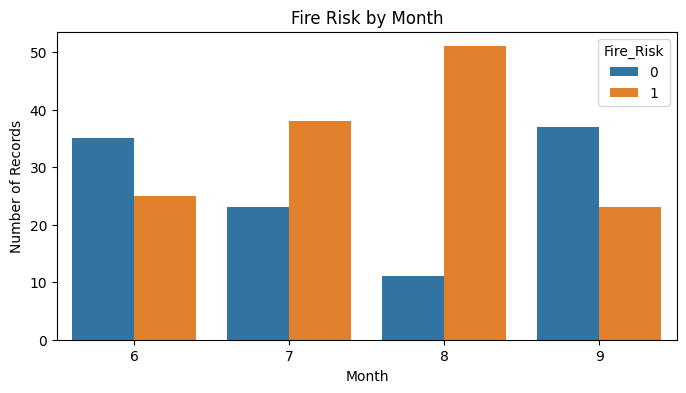

In [ ]:
# ------------------------------------------
# 7️⃣ Month-wise Fire Analysis
# ------------------------------------------

print("\n📅 Fire Risk by Month:")
display(
    pd.crosstab(
        df["month"],
        df["Fire_Risk"],
        normalize="index"
    ).round(3) * 100
)


plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="month",
    hue="Fire_Risk"
)

plt.title("Fire Risk by Month")
plt.xlabel("Month")
plt.ylabel("Number of Records")
plt.show()

In [ ]:
# ------------------------------------------
# 8️⃣ Outlier Detection
# ------------------------------------------

print("\n🚨 Potential Outliers:")

for feature in features:

    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[feature] < lower) |
        (df[feature] > upper)
    ]

    print(f"{feature}: {len(outliers)} outliers")


🚨 Potential Outliers:
Temperature: 2 outliers
RH: 0 outliers
Ws: 8 outliers
Rain: 35 outliers
FFMC: 13 outliers
DMC: 12 outliers
DC: 14 outliers
ISI: 4 outliers
BUI: 11 outliers
FWI: 4 outliers


/tmp/ipykernel_804/4159525438.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fire_Risk', data=df, ax=axes[0], palette=['#2ca02c', '#d62728'])


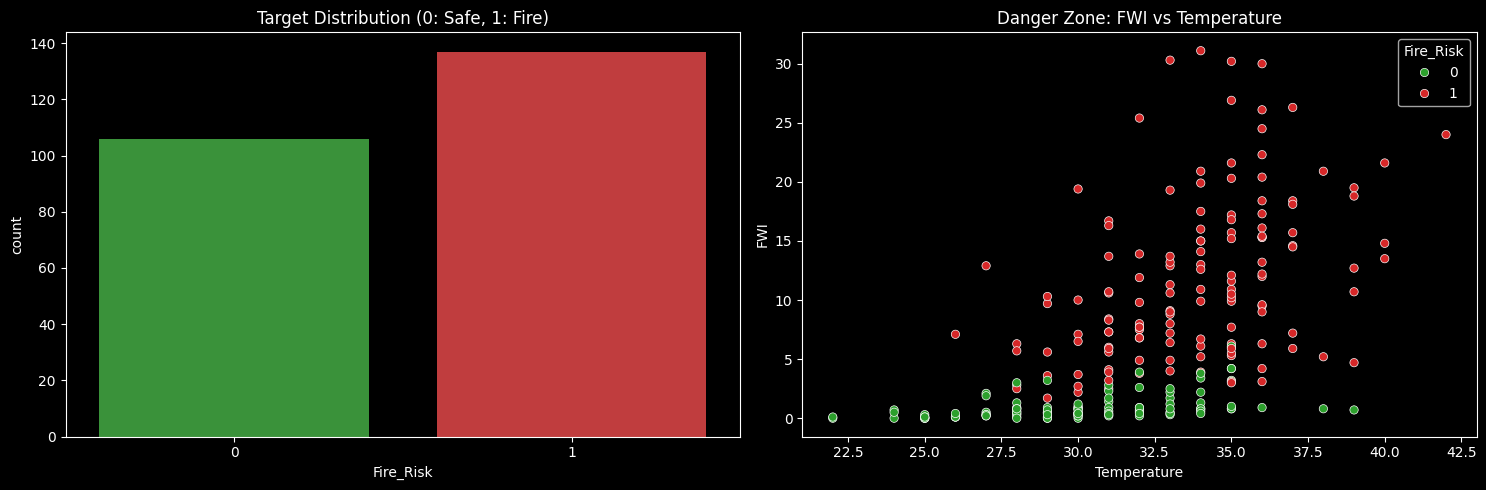

In [ ]:
# ==========================================
# PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Setting a premium dark theme for the visuals
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Visual 1: Target Imbalance Check
sns.countplot(x='Fire_Risk', data=df, ax=axes[0], palette=['#2ca02c', '#d62728'])
axes[0].set_title("Target Distribution (0: Safe, 1: Fire)")

# Visual 2: FWI (Fire Weather Index) vs Temperature
sns.scatterplot(x='Temperature', y='FWI', hue='Fire_Risk', data=df,
                palette=['#2ca02c', '#d62728'], ax=axes[1])
axes[1].set_title("Danger Zone: FWI vs Temperature")
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 🔥 IGNIS-NET AI
# STEP 4 — FEATURE SELECTION & DATA SPLITTING
# ==========================================
# ==========================================
# PHASE 4: DATA SPLITTING
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("⚙️ Initiating Phase 3: Feature Engineering & Data Splitting...\n")

# ------------------------------------------
# 1️⃣ Multicollinearity Handling
# ------------------------------------------
# Dropping 'BUI' and 'DC' because they are highly correlated with 'DMC'
# Dropping 'month' as atmospheric indices (FWI, ISI) already capture seasonal danger better
drop_cols = ['BUI', 'DC', 'month']
df_engineered = df.drop(drop_cols, axis=1)

print(f"🗑️ Dropped Highly Correlated/Redundant Columns: {drop_cols}")
print(f"📊 New Dataset Shape: {df_engineered.shape}\n")


# ------------------------------------------
# 2️⃣ Target & Feature Separation (The Safety Protocol)
# ------------------------------------------
# Model training ya feature sampling se pehle Target column (y) aur Features (X) ko
# alag karna ek bahut zaroori safety protocol hai.
X = df_engineered.drop('Fire_Risk', axis=1)
y = df_engineered['Fire_Risk']

print("🎯 Target (y) and Features (X) successfully separated.")


# ------------------------------------------
# 3️⃣ Stratified Train-Test Split
# ------------------------------------------
# Stratify ensures that both Train and Test data maintain the exact Safe/Hazardous ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"🛡️ Data Splitting Complete (80% Train, 20% Test):")
print(f"   - Training Features: {X_train.shape}")
print(f"   - Testing Features:  {X_test.shape}\n")


# ------------------------------------------
# 4️⃣ Feature Scaling (Optional but Recommended)
# ------------------------------------------
# While Random Forest doesn't strictly require scaling, we scale the data here so
# we can train a Logistic Regression baseline model later for comparison.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability in later steps
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("⚖️ Feature Scaling Complete (StandardScaler applied).")

⚙️ Initiating Phase 3: Feature Engineering & Data Splitting...

🗑️ Dropped Highly Correlated/Redundant Columns: ['BUI', 'DC', 'month']
📊 New Dataset Shape: (243, 12)

🎯 Target (y) and Features (X) successfully separated.
🛡️ Data Splitting Complete (80% Train, 20% Test):
   - Training Features: (194, 11)
   - Testing Features:  (49, 11)

⚖️ Feature Scaling Complete (StandardScaler applied).


⚙️ Initiating Phase 4: The Iron Legion Model Comparison...

✅ Logistic Regression (Baseline) Evaluated.
✅ Decision Tree (High Variance) Evaluated.
✅ Bagging Classifier (Variance Reducer) Evaluated.
✅ Random Forest (Industry Benchmark) Evaluated.

📊 Model Performance & Variance Analysis:


,Model,Test F1-Score,CV F1 Mean,CV F1 Std (Variance)
0,Logistic Regression (Baseline),0.9286,0.9537,0.0323
1,Decision Tree (High Variance),0.9474,0.9581,0.0095
2,Bagging Classifier (Variance Reducer),0.9492,0.9771,0.0204
3,Random Forest (Industry Benchmark),1.0000,0.9771,0.0204


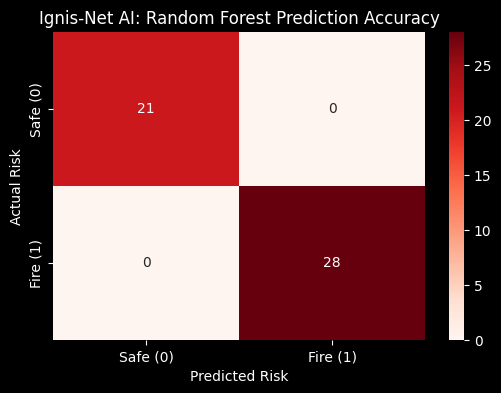

In [ ]:
# ==========================================
# 🔥 IGNIS-NET AI
# STEP 5 — MODEL TRAINING & VARIANCE COMPARISON
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, confusion_matrix

print("⚙️ Initiating Phase 4: The Iron Legion Model Comparison...\n")

# ------------------------------------------
# 1️⃣ Defining the Models (The Armory)
# ------------------------------------------
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree (High Variance)": DecisionTreeClassifier(random_state=42),
    "Bagging Classifier (Variance Reducer)": BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Random Forest (Industry Benchmark)": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

# ------------------------------------------
# 2️⃣ Evaluation Loop (Cross-Validation for Stability)
# ------------------------------------------
results = []

for name, model in models.items():
    # Training the model on the 80% train set
    model.fit(X_train, y_train)

    # Predicting on the 20% unseen test set
    y_pred = model.predict(X_test)
    test_f1 = f1_score(y_test, y_pred)

    # K-Fold Cross Validation (cv=5) on the training data to check stability
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1', n_jobs=-1)
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std() # THIS IS THE MOST IMPORTANT METRIC FOR VARIANCE!

    results.append({
        "Model": name,
        "Test F1-Score": test_f1,
        "CV F1 Mean": cv_mean,
        "CV F1 Std (Variance)": cv_std
    })

    print(f"✅ {name} Evaluated.")

# ------------------------------------------
# 3️⃣ Displaying the Comparison Matrix
# ------------------------------------------
import pandas as pd
results_df = pd.DataFrame(results)
print("\n📊 Model Performance & Variance Analysis:")
display(results_df.round(4))

# ------------------------------------------
# 4️⃣ Visualizing the Winner (Random Forest Confusion Matrix)
# ------------------------------------------
best_model = models["Random Forest (Industry Benchmark)"]
y_pred_rf = best_model.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True, fmt='d', cmap='Reds',
    xticklabels=['Safe (0)', 'Fire (1)'],
    yticklabels=['Safe (0)', 'Fire (1)']
)
plt.title("Ignis-Net AI: Random Forest Prediction Accuracy")
plt.ylabel("Actual Risk")
plt.xlabel("Predicted Risk")
plt.show()

🔍 Initiating Hyperparameter Tuning (GridSearchCV)...
⏳ Tuning the Iron Legion... (Testing all combinations across CPU cores)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
✅ Tuning Complete!
🏆 Optimal Parameters Found: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}

🚀 --- IGNIS-NET AI FINAL DIAGNOSTICS --- 🚀
Tuned F1-Score:  0.9655
Tuned ROC-AUC:   1.0000

📑 Detailed Classification Report:

               precision    recall  f1-score   support

     Safe (0)       1.00      0.90      0.95        21
Fire Risk (1)       0.93      1.00      0.97        28

     accuracy                           0.96        49
    macro avg       0.97      0.95      0.96        49
 weighted avg       0.96      0.96      0.96        49



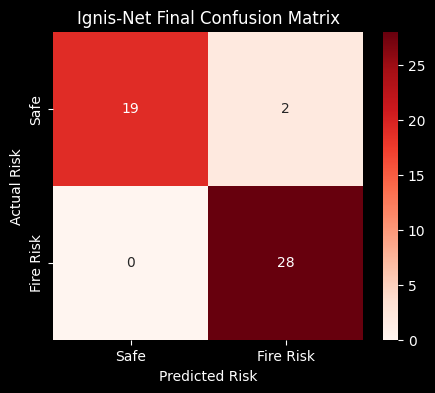


🌍 Top Environmental Triggers (Feature Importance):
1. ISI: 0.3374
2. FFMC: 0.2596
3. FWI: 0.2145
4. DMC: 0.0955
5. Rain: 0.0401


In [ ]:
# ==========================================
# 🔥 IGNIS-NET AI
# STEP 6 — HYPERPARAMETER TUNING & EVALUATION
# ==========================================

# ==========================================
# PHASE 6: THE IRON LEGION (GridSearchCV + Random Forest)
# ==========================================

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("🔍 Initiating Hyperparameter Tuning (GridSearchCV)...")

# ------------------------------------------
# 1️⃣ Defining the Parameter Grid
# ------------------------------------------
param_grid = {
    'n_estimators': [100, 200, 300],      # Total number of trees in the forest[cite: 4].
    'max_depth': [10, 20, None],          # Controls maximum depth to prevent deep overfitting
    'max_features': ['sqrt', 'log2'],     # Decides the fraction of columns given to each tree.
    'min_samples_split': [2, 5],
    'bootstrap': [True]                   # Enables sampling with replacement
}

# ------------------------------------------
# 2️⃣ Base Model & Grid Search Setup
# ------------------------------------------
# Using class_weight='balanced' automatically handles any remaining target imbalance
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced')

# We strictly optimize for 'f1' instead of accuracy because F1-score balances precision and recall,
# which is the targeted metric for imbalanced data where false negatives are dangerous[cite: 1].
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# ------------------------------------------
# 3️⃣ Executing the Tuning Process
# ------------------------------------------
print("⏳ Tuning the Iron Legion... (Testing all combinations across CPU cores)\n")
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("✅ Tuning Complete!")
print(f"🏆 Optimal Parameters Found: {grid_search.best_params_}\n")


# ==========================================
# 🚀 FINAL SYSTEM EVALUATION
# ==========================================
y_pred = best_rf.predict(X_test)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

print("🚀 --- IGNIS-NET AI FINAL DIAGNOSTICS --- 🚀")
print(f"Tuned F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Tuned ROC-AUC:   {roc_auc_score(y_test, y_pred_proba):.4f}\n")

print("📑 Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Safe (0)', 'Fire Risk (1)']))

# ------------------------------------------
# Visualizing the Final Confusion Matrix
# ------------------------------------------
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds',
            xticklabels=['Safe', 'Fire Risk'], yticklabels=['Safe', 'Fire Risk'])
plt.title("Ignis-Net Final Confusion Matrix")
plt.ylabel("Actual Risk")
plt.xlabel("Predicted Risk")
plt.show()

# ==========================================
# 📊 FEATURE IMPORTANCE (The Business Logic)
# ==========================================
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

print("\n🌍 Top Environmental Triggers (Feature Importance):")
for i in range(min(5, len(features))):
    print(f"{i+1}. {features[indices[i]]}: {importances[indices[i]]:.4f}")

In [ ]:
# ==========================================
# 🔥 IGNIS-NET AI
# STEP 7 — 3-TIER RISK SYSTEM & MODEL EXPORT
# ==========================================

import pickle

print("🚀 Initiating Phase 6: Advanced Evaluation & Dashboard Logic...\n")

# ------------------------------------------
# 1️⃣ Extracting Probabilities
# ------------------------------------------
# predict_proba returns an array: [Probability of 0, Probability of 1]
# We only need the probability of Fire Risk (Index 1)
y_pred_proba = best_rf.predict_proba(X_test)[:, 1]

# ------------------------------------------
# 2️⃣ The 3-Tier Dashboard Engine
# ------------------------------------------
def get_dashboard_risk(probability):
    if probability <= 0.35:
        return "🟢 LOW RISK"
    elif 0.35 < probability <= 0.70:
        return "🟠 MEDIUM RISK"
    else:
        return "🔴 HIGH RISK"

# ------------------------------------------
# 3️⃣ Live Dashboard Simulation
# ------------------------------------------
print("📊 Live Dashboard Risk Assessment (First 5 Test Regions):")
for i in range(5):
    prob = y_pred_proba[i]
    risk_level = get_dashboard_risk(prob)
    print(f"Region {i+1} | Fire Probability: {prob*100:.1f}% | UI Alert: {risk_level}")

# ------------------------------------------
# 4️⃣ Exporting the Iron Legion
# ------------------------------------------
model_filename = "ignis_net_rf.pkl"

with open(model_filename, 'wb') as file:
    pickle.dump(best_rf, file)

print(f"\n✅ SUCCESS: Model packed and saved as '{model_filename}'.")

🚀 Initiating Phase 6: Advanced Evaluation & Dashboard Logic...

📊 Live Dashboard Risk Assessment (First 5 Test Regions):
Region 1 | Fire Probability: 0.0% | UI Alert: 🟢 LOW RISK
Region 2 | Fire Probability: 51.0% | UI Alert: 🟠 MEDIUM RISK
Region 3 | Fire Probability: 0.0% | UI Alert: 🟢 LOW RISK
Region 4 | Fire Probability: 0.0% | UI Alert: 🟢 LOW RISK
Region 5 | Fire Probability: 0.0% | UI Alert: 🟢 LOW RISK

✅ SUCCESS: Model packed and saved as 'ignis_net_rf.pkl'.
